In [15]:
import sys
sys.path.insert(0, "/home/zbezjak/code/donismous/Climate-Resilience")  # repo root
import os
os.chdir("/home/zbezjak/code/donismous/Climate-Resilience")

import warnings
import numpy as np
import pandas as pd

from model.composite_risk_score import compute_composite_risk
from model.arima import fit_arima, prepare_series
from model.arima import forecast as arima_forecast
from model.exp_smoothing import fit_ets
from model.exp_smoothing import forecast as ets_forecast

TEST_YEARS = 5
MIN_TRAIN_POINTS = 10

In [16]:
def _metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    errors = predicted - actual
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors**2))
    mape = np.nan if np.any(actual == 0) else np.mean(np.abs(errors / actual)) * 100
    return {"mae": mae, "rmse": rmse, "mape": mape}

def backtest_one_country(series, test_years=TEST_YEARS):
    if len(series) < MIN_TRAIN_POINTS + test_years:
        return {"arima": None, "ets": None}
    train, test = series.iloc[:-test_years], series.iloc[-test_years:]
    result = {"arima": None, "ets": None}
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            pred = arima_forecast(fit_arima(train), steps=test_years)
            result["arima"] = _metrics(test.values, pred["forecast"].values)
        except Exception as exc:
            result["arima"] = {"error": str(exc)}
        try:
            pred = ets_forecast(fit_ets(train), steps=test_years)
            result["ets"] = _metrics(test.values, pred["forecast"].values)
        except Exception as exc:
            result["ets"] = {"error": str(exc)}
    return result

def run_backtest(risk_df, test_years=TEST_YEARS, countries=None):
    if countries is None:
        countries = sorted(risk_df["Country"].unique())
    rows = []
    for country in countries:
        try:
            series = prepare_series(risk_df, country, 'risk_score')
        except ValueError:
            continue
        result = backtest_one_country(series, test_years=test_years)
        if result["arima"] is None and result["ets"] is None:
            continue
        for model_name in ("arima", "ets"):
            m = result[model_name]
            if m is None:
                continue
            rows.append({"country": country, "model": model_name,
                         "mae": m.get("mae"), "rmse": m.get("rmse"),
                         "mape": m.get("mape"), "error": m.get("error")})
    return pd.DataFrame(rows)

def summarize_backtest(backtest_df):
    valid = backtest_df[backtest_df["error"].isna()]
    failed = backtest_df[backtest_df["error"].notna()].groupby("model").size()
    summary = valid.groupby("model").agg(
        mean_mae=("mae", "mean"), median_mae=("mae", "median"),
        mean_rmse=("rmse", "mean"), median_rmse=("rmse", "median"),
        mean_mape=("mape", "mean"), median_mape=("mape", "median"),
        n_countries=("mae", "count"),
    )
    summary["n_failed"] = failed.reindex(summary.index).fillna(0).astype(int)
    return summary

def head_to_head_win_rate(backtest_df):
    valid = backtest_df[backtest_df["error"].isna()]
    pivot = valid.pivot(index="country", columns="model", values="mae").dropna()
    winner = np.where(pivot["arima"] < pivot["ets"], "arima",
                       np.where(pivot["arima"] > pivot["ets"], "ets", "tie"))
    return pd.Series(winner).value_counts()

In [17]:
df = pd.read_csv("data/data_preprocessed/processed_data.csv")
risk_df = compute_composite_risk(df)

backtest = run_backtest(risk_df, test_years=5)
summary = summarize_backtest(backtest)
summary

ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(1, 0, 3) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(2, 0, 3) did not converge, falling back to ARIMA(2, 0, 0)
ARIMA(1, 0, 3) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(1, 0, 3) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(3, 0, 2) did not converge, falling back to ARIMA(3, 0, 0)
ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(2, 0, 4) did not converge, falling back to ARIMA(2, 0, 0)
ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(1, 0, 3) did not converge, falling

,mean_mae,median_mae,mean_rmse,median_rmse,mean_mape,median_mape,n_countries,n_failed
model,,,,,,,,
arima,0.009312,0.007423,0.010183,0.008133,1.937891,1.409515,186,0
ets,0.009309,0.007823,0.010301,0.008502,1.962576,1.597662,186,0


In [18]:
head_to_head_win_rate(backtest)

ets      97
arima    89
Name: count, dtype: int64

In [19]:
import os
print(os.getcwd())

/home/zbezjak/code/donismous/Climate-Resilience


In [20]:
arima_df = pd.read_csv("data/outputs/risk_score_with_forecast.csv")
ets_df = pd.read_csv("data/outputs/risk_score_with_ets_forecast.csv")

arima_fc = arima_df[arima_df["source"] == "forecast"][["country", "year", "risk_score", "lower", "upper"]] \
    .rename(columns={"risk_score": "arima_forecast", "lower": "arima_lower", "upper": "arima_upper"})
ets_fc = ets_df[ets_df["source"] == "forecast"][["country", "year", "risk_score", "lower", "upper"]] \
    .rename(columns={"risk_score": "ets_forecast", "lower": "ets_lower", "upper": "ets_upper"})

merged = arima_fc.merge(ets_fc, on=["country", "year"]).sort_values(["country", "year"])
merged["diff"] = merged["ets_forecast"] - merged["arima_forecast"]

merged.groupby("year").apply(lambda g: pd.Series({
    "mean_abs_diff": g["diff"].abs().mean(),
    "correlation": g["arima_forecast"].corr(g["ets_forecast"]),
}))

/tmp/ipykernel_111505/3948546375.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged.groupby("year").apply(lambda g: pd.Series({


,mean_abs_diff,correlation
year,,
2024,0.002797,0.999645
2025,0.005221,0.998909
2026,0.007580,0.997876
2027,0.009840,0.996585
2028,0.012003,0.995084
2029,0.014043,0.993424
2030,0.016004,0.991620
2031,0.017889,0.989681
2032,0.019719,0.987615


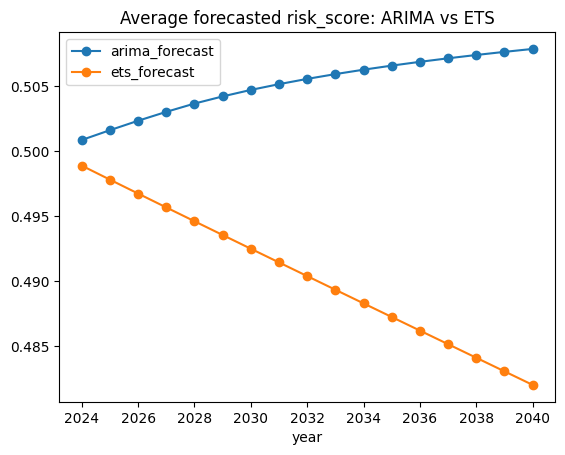

In [21]:
import matplotlib.pyplot as plt

by_year = merged.groupby("year")[["arima_forecast", "ets_forecast"]].mean()
by_year.plot(marker="o", title="Average forecasted risk_score: ARIMA vs ETS")
plt.show()

In [22]:
ets_df = pd.read_csv("data/outputs/risk_score_with_ets_forecast.csv")
forecasts = ets_df[ets_df["source"] == "forecast"]
print("Min risk_score:", forecasts["risk_score"].min())
print("Max risk_score:", forecasts["risk_score"].max())
print("Rows below 0:", (forecasts["risk_score"] < 0).sum())
print("Rows above 1:", (forecasts["risk_score"] > 1).sum())

Min risk_score: 0.2041027087702368
Max risk_score: 0.7454527692559626
Rows below 0: 0
Rows above 1: 0


In [25]:
import pandas as pd

ets_df = pd.read_csv("data/outputs/risk_score_with_ets_forecast.csv")
forecasts = ets_df[ets_df["source"] == "forecast"]

results = []
for country, group in forecasts.groupby("country"):
    group = group.sort_values("year")
    if len(group) < 4:
        continue
    early_slope = group["risk_score"].diff().iloc[1:3].mean()
    late_slope = group["risk_score"].diff().iloc[-3:].mean()
    slope_ratio = late_slope / early_slope if early_slope != 0 else float("nan")
    results.append({
        "country": country,
        "early_slope": early_slope,
        "late_slope": late_slope,
        "slope_ratio": slope_ratio,
    })

slopes_df = pd.DataFrame(results)

# If late_slope is close to early_slope (ratio near 1), the trend hasn't
# tapered -> looks undamped/linear. If late_slope is much smaller in
# magnitude than early_slope (ratio near 0), the trend has flattened out
# -> looks damped.
roughly_linear = slopes_df[slopes_df["slope_ratio"].between(0.85, 1.15)]
clearly_damped = slopes_df[slopes_df["slope_ratio"].abs() < 0.5]

print(f"Total countries checked: {len(slopes_df)}")
print(f"Roughly linear (undamped-looking): {len(roughly_linear)}")
print(f"Clearly damped (slope tapering): {len(clearly_damped)}")
print(slopes_df.sort_values("slope_ratio").head(10))

Total countries checked: 186
Roughly linear (undamped-looking): 170
Clearly damped (slope tapering): 15
    country  early_slope  late_slope  slope_ratio
172     UGA    -0.000130   -0.000006     0.049682
166     TLS    -0.000448   -0.000022     0.049682
136     POL    -0.000306   -0.000015     0.049682
110     MKD    -0.000458   -0.000023     0.049682
32      CIV    -0.000769   -0.000038     0.049682
176     UZB    -0.001982   -0.000098     0.049682
153     STP    -0.001094   -0.000054     0.049682
52      ESP    -0.000016   -0.000001     0.073596
135     PNG     0.000208    0.000020     0.093898
132     PER     0.000470    0.000057     0.120481


In [26]:
import pandas as pd
from model.composite_risk_score import compute_composite_risk
from model.exp_smoothing import fit_ets
from model.arima import prepare_series

df = pd.read_csv("data/data_preprocessed/processed_data.csv")
risk = compute_composite_risk(df)

rows = []
for country in sorted(risk["Country"].unique()):
    series = prepare_series(risk, country, "risk_score")
    if len(series) < 4:
        continue
    result = fit_ets(series)
    rows.append({
        "country": country,
        "damped": result.model.damped_trend,
        "phi": result.params.get("damping_trend", None),
        "aic": result.aic,
    })

fit_info = pd.DataFrame(rows)
print(fit_info["damped"].value_counts())
print(fit_info[fit_info["damped"]]["phi"].describe())

damped
False    170
True      16
Name: count, dtype: int64
count    16.000000
mean      0.852839
std       0.058970
min       0.800000
25%       0.800000
50%       0.831326
75%       0.900902
max       0.958208
Name: phi, dtype: float64


In [27]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

from model.composite_risk_score import compute_composite_risk
from model.arima import prepare_series

df = pd.read_csv("data/data_preprocessed/processed_data.csv")
risk = compute_composite_risk(df)

rows = []
for country in sorted(risk["Country"].unique()):
    series = prepare_series(risk, country, "risk_score")
    if len(series) < 4:
        continue

    years = series.index.year.values.astype(float)
    values = series.values.astype(float)

    slope, intercept, r_value, p_value, std_err = linregress(years, values)
    rows.append({
        "country": country,
        "slope_per_year": slope,
        "p_value": p_value,
        "significant": p_value < 0.05,
        "n_years": len(series),
    })

trend_df = pd.DataFrame(rows)

sig = trend_df[trend_df["significant"]]
print(f"Total countries: {len(trend_df)}")
print(f"Statistically significant trend (p<0.05): {len(sig)}")
print(f"  Rising (slope > 0): {(sig['slope_per_year'] > 0).sum()}")
print(f"  Falling (slope < 0): {(sig['slope_per_year'] < 0).sum()}")
print(f"No significant trend: {len(trend_df) - len(sig)}")
print()
print("Overall slope distribution (all countries, regardless of significance):")
print(trend_df["slope_per_year"].describe())

Total countries: 186
Statistically significant trend (p<0.05): 148
  Rising (slope > 0): 18
  Falling (slope < 0): 130
No significant trend: 38

Overall slope distribution (all countries, regardless of significance):
count    186.000000
mean      -0.001292
std        0.001416
min       -0.005844
25%       -0.002207
50%       -0.001270
75%       -0.000340
max        0.003369
Name: slope_per_year, dtype: float64


In [28]:
import pandas as pd
from model.composite_risk_score import compute_composite_risk
from model.exp_smoothing import fit_ets
from model.arima import prepare_series
from scipy.stats import linregress

df = pd.read_csv("data/data_preprocessed/processed_data.csv")
risk = compute_composite_risk(df)

rows = []
for country in sorted(risk["Country"].unique()):
    series = prepare_series(risk, country, "risk_score")
    if len(series) < 4:
        continue

    # Real historical trend (ground truth, independent of any model)
    years = series.index.year.values.astype(float)
    values = series.values.astype(float)
    slope, intercept, r_value, p_value, std_err = linregress(years, values)

    # ETS's own damping decision
    result = fit_ets(series)

    rows.append({
        "country": country,
        "slope_per_year": slope,
        "p_value": p_value,
        "significant": p_value < 0.05,
        "abs_slope": abs(slope),
        "damped": result.model.damped_trend,
    })

merged = pd.DataFrame(rows)

print("Mean |historical slope| by damping decision:")
print(merged.groupby("damped")["abs_slope"].agg(["mean", "median", "count"]))
print()

print("Significance rate by damping decision:")
print(merged.groupby("damped")["significant"].mean())
print()

print("Mean p-value by damping decision (lower = stronger evidence of a real trend):")
print(merged.groupby("damped")["p_value"].agg(["mean", "median"]))

Mean |historical slope| by damping decision:
            mean    median  count
damped                           
False   0.001555  0.001356    170
True    0.001433  0.001370     16

Significance rate by damping decision:
damped
False    0.80
True     0.75
Name: significant, dtype: float64

Mean p-value by damping decision (lower = stronger evidence of a real trend):
            mean        median
damped                        
False   0.071673  1.472132e-07
True    0.131045  1.019620e-05
